# Income Fairness Audit

Audit of logistic regression income predictions on the UCI Adult benchmark. The analysis compares outcomes across the dataset’s recorded `sex` categories, examines model explanations, and tests hypothetical recourse. An income label is not a measure of hiring qualification.

Run all cells from the repository root or the `notebooks` directory after installing `requirements.txt`. The same analysis is available in `src/audit.py`.

In [1]:
from pathlib import Path
import json
import hashlib
import platform
import importlib.metadata
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

if 'DATA_PATH' not in globals():
    project_root = Path.cwd()
    if not (project_root / 'data/adult.data').exists():
        project_root = project_root.parent
    DATA_PATH = project_root / 'data/adult.data'
    OUTPUT_DIR = project_root / 'results'
DATA_PATH = Path(DATA_PATH)
OUTPUT_DIR = Path(OUTPUT_DIR)
(OUTPUT_DIR / 'figures').mkdir(parents=True, exist_ok=True)
np.random.seed(42)

def save_figure(filename):
    plt.savefig(OUTPUT_DIR / 'figures' / filename, dpi=160, bbox_inches='tight')
    plt.show()
    plt.close()

columns = [
    'age', 'workclass', 'fnlwgt', 'education', 'education_num',
    'marital_status', 'occupation', 'relationship', 'race', 'sex',
    'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income'
]
df_raw = pd.read_csv(DATA_PATH, names=columns, sep=',', skipinitialspace=True)
df = df_raw.replace('?', 'Unknown').copy()
income_labels = df['income'].astype(str).str.strip().str.rstrip('.')
if not income_labels.isin(['<=50K', '>50K']).all():
    raise ValueError('Unexpected income label in input data')
df['income'] = (income_labels == '>50K').astype(int)
print('Raw dataset shape:', df_raw.shape)
print('Cleaned dataset shape:', df.shape)
display(df.head())


Raw dataset shape: (32561, 15)
Cleaned dataset shape: (32561, 15)


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,0
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,0
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,0
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,0
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,0


workclass         1836
occupation        1843
native_country     583
dtype: int64


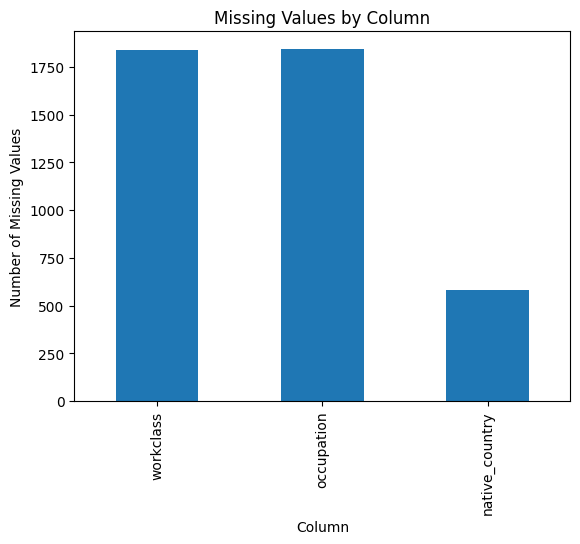

In [2]:

missing_counts = (df_raw == "?").sum()
print(missing_counts[missing_counts > 0])

missing_counts[missing_counts > 0].plot(kind="bar")
plt.title("Missing Values by Column")
plt.xlabel("Column")
plt.ylabel("Number of Missing Values")
save_figure("missing_values.png")

## EDA Analysis

## Sex VS income

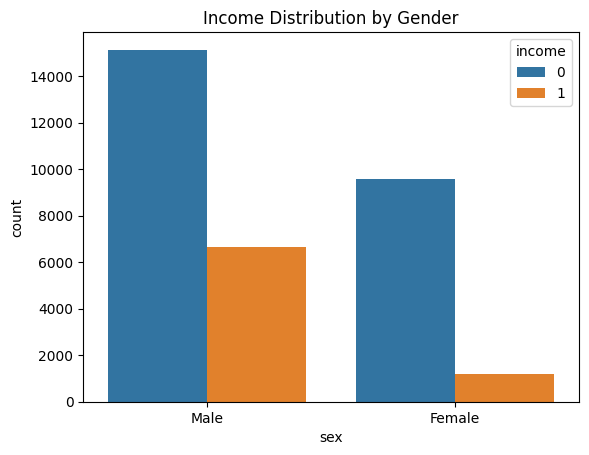

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(data=df, x="sex", hue="income")
plt.title("Income Distribution by Gender")
save_figure("income_by_sex.png")

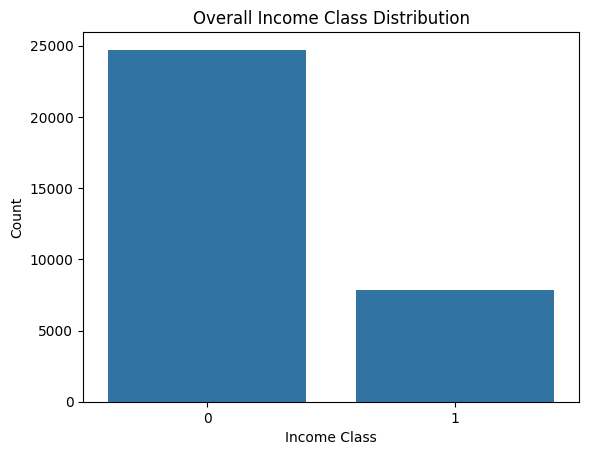

In [4]:
sns.countplot(data=df, x="income")
plt.title("Overall Income Class Distribution")
plt.xlabel("Income Class")
plt.ylabel("Count")
save_figure("income_distribution.png")

## education VS income

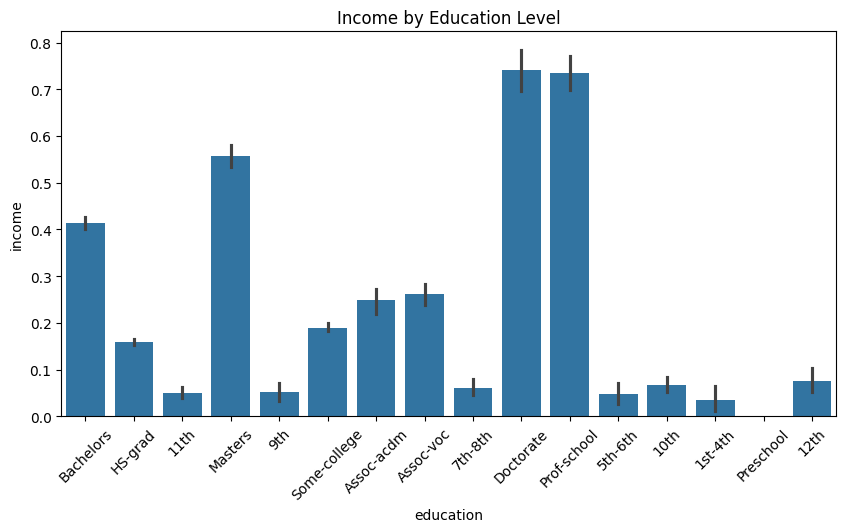

In [5]:
plt.figure(figsize=(10,5))
sns.barplot(data=df, x="education", y="income")
plt.xticks(rotation=45)
plt.title("Income by Education Level")
save_figure("income_by_education.png")

## Work-time VS income

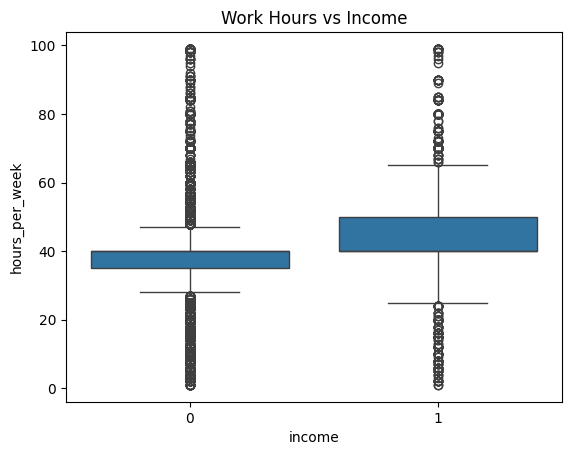

In [6]:
sns.boxplot(data=df, x="income", y="hours_per_week")
plt.title("Work Hours vs Income")
save_figure("work_hours_by_income.png")

## ## Model training

In [7]:
# Features and target
X_raw = df.drop("income", axis=1)
y = df["income"]

# One-hot encoding
X = pd.get_dummies(X_raw)

# Train-test split
# stratify=y helps keep class balance similar in train/test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Scaling helps Logistic Regression converge better
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert scaled arrays back to DataFrames for SHAP readability
X_train_scaled_df = pd.DataFrame(
    X_train_scaled,
    columns=X.columns,
    index=X_train.index
)

X_test_scaled_df = pd.DataFrame(
    X_test_scaled,
    columns=X.columns,
    index=X_test.index
)

# Train model
model = LogisticRegression(max_iter=5000, C=1.0, solver="lbfgs", random_state=42)
model.fit(X_train_scaled_df, y_train)

# Predictions
y_pred = model.predict(X_test_scaled_df)
y_prob = model.predict_proba(X_test_scaled_df)[:, 1]

print("Overall Model Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_prob))
overall_metrics = pd.DataFrame([{
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred),
    "recall": recall_score(y_test, y_pred),
    "f1": f1_score(y_test, y_pred),
    "roc_auc": roc_auc_score(y_test, y_prob),
    "majority_class_accuracy": float((y_test == 0).mean())
}])


Overall Model Performance:
Accuracy: 0.8549055734684478
Precision: 0.7365223993925588
Recall: 0.6186224489795918
F1: 0.6724436741767764
AUC: 0.909332375518458


## Fairness Metrics by Gender

In [8]:
df_test = pd.DataFrame(index=X_test.index)

df_test["true"] = y_test
df_test["pred"] = y_pred
df_test["prob"] = y_prob

# Get protected attribute from original df
df_test["sex"] = df.loc[X_test.index, "sex"]

display(df_test.head())

def safe_divide(a, b):
    if b == 0:
        return np.nan
    return a / b


def compute_group_metrics(df_eval, group_col):
    rows = []

    for group in sorted(df_eval[group_col].unique()):
        subset = df_eval[df_eval[group_col] == group]

        y_true_g = subset["true"]
        y_pred_g = subset["pred"]

        tn, fp, fn, tp = confusion_matrix(
            y_true_g,
            y_pred_g,
            labels=[0, 1]
        ).ravel()

        n = len(subset)

        positive_prediction_rate = safe_divide(tp + fp, n)
        actual_positive_rate = safe_divide(tp + fn, n)

        accuracy = safe_divide(tp + tn, n)

        # Equality of opportunity uses TPR
        tpr = safe_divide(tp, tp + fn)

        # Equalized odds looks at both TPR and FPR
        fpr = safe_divide(fp, fp + tn)

        # Predictive parity usually compares PPV / precision
        ppv = safe_divide(tp, tp + fp)

        fnr = safe_divide(fn, fn + tp)
        npv = safe_divide(tn, tn + fn)

        rows.append({
            "group": group,
            "n": n,
            "actual_positive_rate": actual_positive_rate,
            "positive_prediction_rate_demographic_parity": positive_prediction_rate,
            "accuracy": accuracy,
            "tpr_equal_opportunity": tpr,
            "fpr_equalized_odds": fpr,
            "fnr": fnr,
            "ppv_predictive_parity": ppv,
            "npv": npv,
            "tp": tp,
            "fp": fp,
            "tn": tn,
            "fn": fn
        })

    return pd.DataFrame(rows)


group_metrics = compute_group_metrics(df_test, "sex")
display(group_metrics)


,true,pred,prob,sex
9009,0,0,0.125216,Male
25134,0,0,0.005151,Male
16682,1,1,0.994118,Male
27044,1,0,0.486439,Male
3302,0,0,0.136833,Male


,group,n,actual_positive_rate,positive_prediction_rate_demographic_parity,accuracy,tpr_equal_opportunity,fpr_equalized_odds,fnr,ppv_predictive_parity,npv,tp,fp,tn,fn
0,Female,2158,0.113531,0.085264,0.930028,0.567347,0.023523,0.432653,0.755435,0.946302,139,45,1868,106
1,Male,4355,0.303789,0.260161,0.817681,0.628118,0.099604,0.371882,0.733451,0.847300,831,302,2730,492


## Fairness Disparity Table

In [9]:
fairness_metrics_to_compare = [
    "actual_positive_rate",
    "positive_prediction_rate_demographic_parity",
    "tpr_equal_opportunity",
    "fpr_equalized_odds",
    "ppv_predictive_parity",
    "accuracy"
]

gap_rows = []

for metric in fairness_metrics_to_compare:
    max_value = group_metrics[metric].max()
    min_value = group_metrics[metric].min()

    gap = max_value - min_value
    ratio = safe_divide(min_value, max_value)

    group_with_max = group_metrics.loc[group_metrics[metric].idxmax(), "group"]
    group_with_min = group_metrics.loc[group_metrics[metric].idxmin(), "group"]

    gap_rows.append({
        "metric": metric,
        "max_group": group_with_max,
        "max_value": max_value,
        "min_group": group_with_min,
        "min_value": min_value,
        "absolute_gap": gap,
        "min_to_max_ratio": ratio
    })

disparity_table = pd.DataFrame(gap_rows)
display(disparity_table)

,metric,max_group,max_value,min_group,min_value,absolute_gap,min_to_max_ratio
0,actual_positive_rate,Male,0.303789,Female,0.113531,0.190258,0.373717
1,positive_prediction_rate_demographic_parity,Male,0.260161,Female,0.085264,0.174897,0.327736
2,tpr_equal_opportunity,Male,0.628118,Female,0.567347,0.060771,0.903249
3,fpr_equalized_odds,Male,0.099604,Female,0.023523,0.076081,0.236167
4,ppv_predictive_parity,Female,0.755435,Male,0.733451,0.021984,0.970899
5,accuracy,Female,0.930028,Male,0.817681,0.112347,0.879200


## Fairness Metrics Visualization

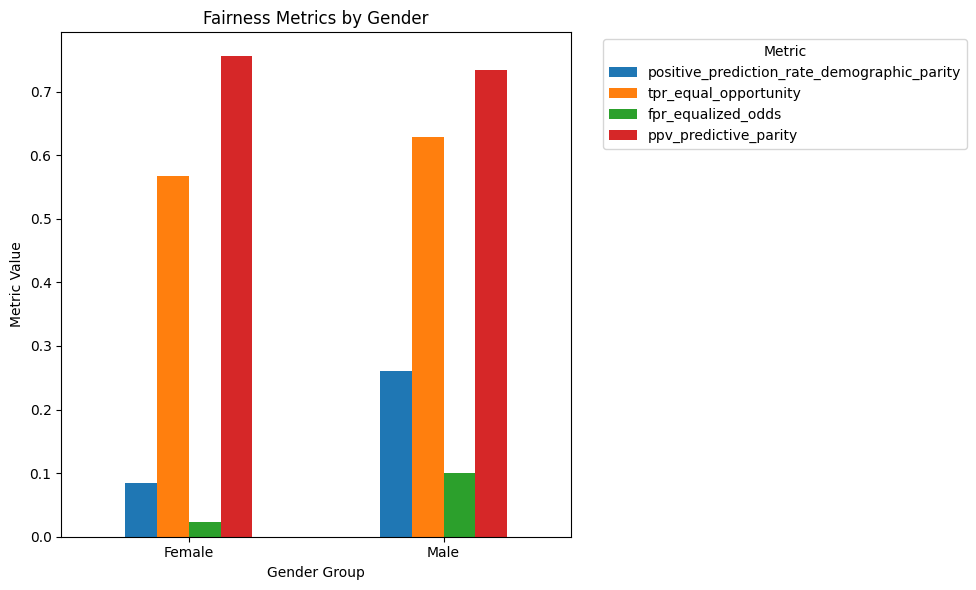

In [10]:
plot_metrics = [
    "positive_prediction_rate_demographic_parity",
    "tpr_equal_opportunity",
    "fpr_equalized_odds",
    "ppv_predictive_parity"
]

group_metrics_plot = group_metrics.set_index("group")[plot_metrics]

ax = group_metrics_plot.plot(kind="bar", figsize=(10, 6))
plt.title("Fairness Metrics by Gender")
plt.xlabel("Gender Group")
plt.ylabel("Metric Value")
plt.xticks(rotation=0)
plt.legend(title="Metric", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
save_figure("group_fairness.png")

## Threshold sensitivity

In [11]:
threshold_rows = []

for threshold in np.arange(0.10, 0.91, 0.05):
    temp_df = df_test.copy()
    temp_df["pred"] = (temp_df["prob"] >= threshold).astype(int)

    temp_group_metrics = compute_group_metrics(temp_df, "sex")

    dp_gap = (
        temp_group_metrics["positive_prediction_rate_demographic_parity"].max()
        - temp_group_metrics["positive_prediction_rate_demographic_parity"].min()
    )

    tpr_gap = (
        temp_group_metrics["tpr_equal_opportunity"].max()
        - temp_group_metrics["tpr_equal_opportunity"].min()
    )

    fpr_gap = (
        temp_group_metrics["fpr_equalized_odds"].max()
        - temp_group_metrics["fpr_equalized_odds"].min()
    )

    ppv_gap = (
        temp_group_metrics["ppv_predictive_parity"].max()
        - temp_group_metrics["ppv_predictive_parity"].min()
    )

    overall_accuracy = accuracy_score(temp_df["true"], temp_df["pred"])

    threshold_rows.append({
        "threshold": round(threshold, 2),
        "overall_accuracy": overall_accuracy,
        "demographic_parity_gap": dp_gap,
        "equal_opportunity_tpr_gap": tpr_gap,
        "equalized_odds_fpr_gap": fpr_gap,
        "predictive_parity_ppv_gap": ppv_gap
    })

threshold_conflict = pd.DataFrame(threshold_rows)
display(threshold_conflict)



,threshold,overall_accuracy,demographic_parity_gap,equal_opportunity_tpr_gap,equalized_odds_fpr_gap,predictive_parity_ppv_gap
0,0.10,0.715953,0.414516,0.080272,0.356745,0.012220
1,0.15,0.761093,0.381073,0.113681,0.299775,0.006663
2,0.20,0.792876,0.350557,0.130159,0.255138,0.007147
3,0.25,0.813604,0.321844,0.117007,0.223389,0.044947
4,0.30,0.829265,0.286349,0.114437,0.181565,0.028925
5,0.35,0.839859,0.249738,0.122298,0.141253,0.006986
6,0.40,0.846154,0.219298,0.113530,0.111769,0.004501
7,0.45,0.851374,0.197571,0.086017,0.094600,0.019048
8,0.50,0.854906,0.174897,0.060771,0.076081,0.021984
9,0.55,0.853831,0.151997,0.046863,0.058439,0.007516


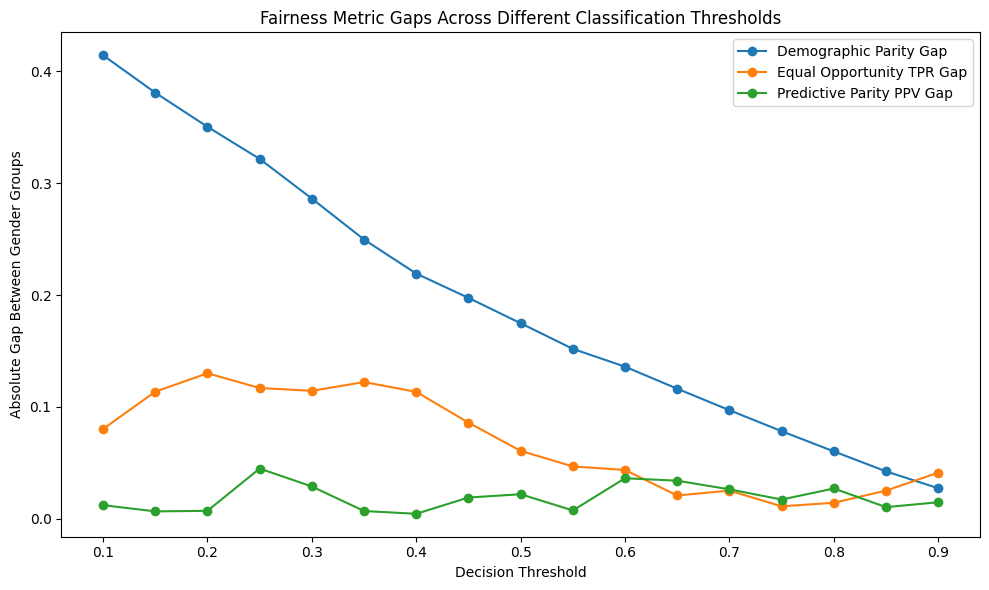

In [12]:
plt.figure(figsize=(10, 6))

plt.plot(
    threshold_conflict["threshold"],
    threshold_conflict["demographic_parity_gap"],
    marker="o",
    label="Demographic Parity Gap"
)

plt.plot(
    threshold_conflict["threshold"],
    threshold_conflict["equal_opportunity_tpr_gap"],
    marker="o",
    label="Equal Opportunity TPR Gap"
)

plt.plot(
    threshold_conflict["threshold"],
    threshold_conflict["predictive_parity_ppv_gap"],
    marker="o",
    label="Predictive Parity PPV Gap"
)

plt.title("Fairness Metric Gaps Across Different Classification Thresholds")
plt.xlabel("Decision Threshold")
plt.ylabel("Absolute Gap Between Gender Groups")
plt.legend()
plt.tight_layout()
save_figure("threshold_tradeoffs.png")

## SHAP Global Explainability

In [13]:
import shap



print("Initializing SHAP LinearExplainer...")

shap_explainer = shap.LinearExplainer(
    model,
    X_train_scaled_df
)

print("Computing SHAP values on full test set...")

shap_exp = shap_explainer(X_test_scaled_df)

shap_values = shap_exp.values

# Safety check for possible 3D output
if len(shap_values.shape) == 3:
    shap_values = shap_values[:, :, 1]

print("SHAP values shape:", shap_values.shape)

Initializing SHAP LinearExplainer...
Computing SHAP values on full test set...
SHAP values shape: (6513, 108)


Background dataset has 26048 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=26048 when initializing the masker.


## SHAP Summary Plot

<ipython-input-1-ac5076cffddc>:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


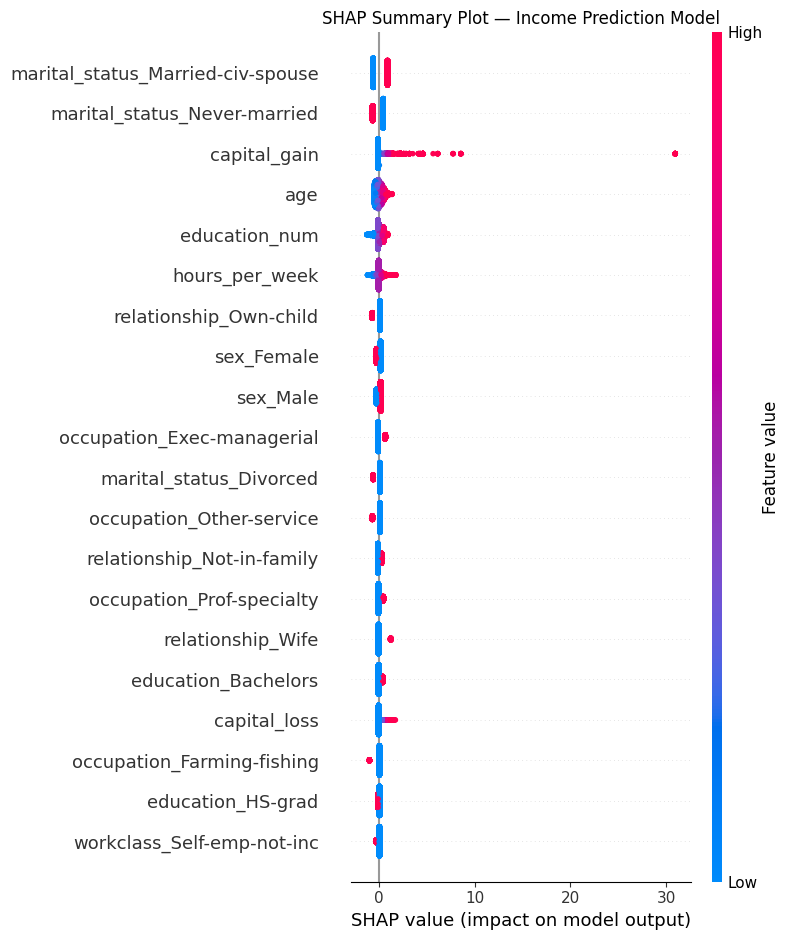

In [14]:
shap.summary_plot(
    shap_values,
    X_test_scaled_df,
    feature_names=X.columns.tolist(),
    show=False
)

plt.title("SHAP Summary Plot — Income Prediction Model")
plt.tight_layout()
save_figure("shap_summary.png")

## SHAP Bar Plot: Top Features

<ipython-input-1-c0bcf3857620>:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


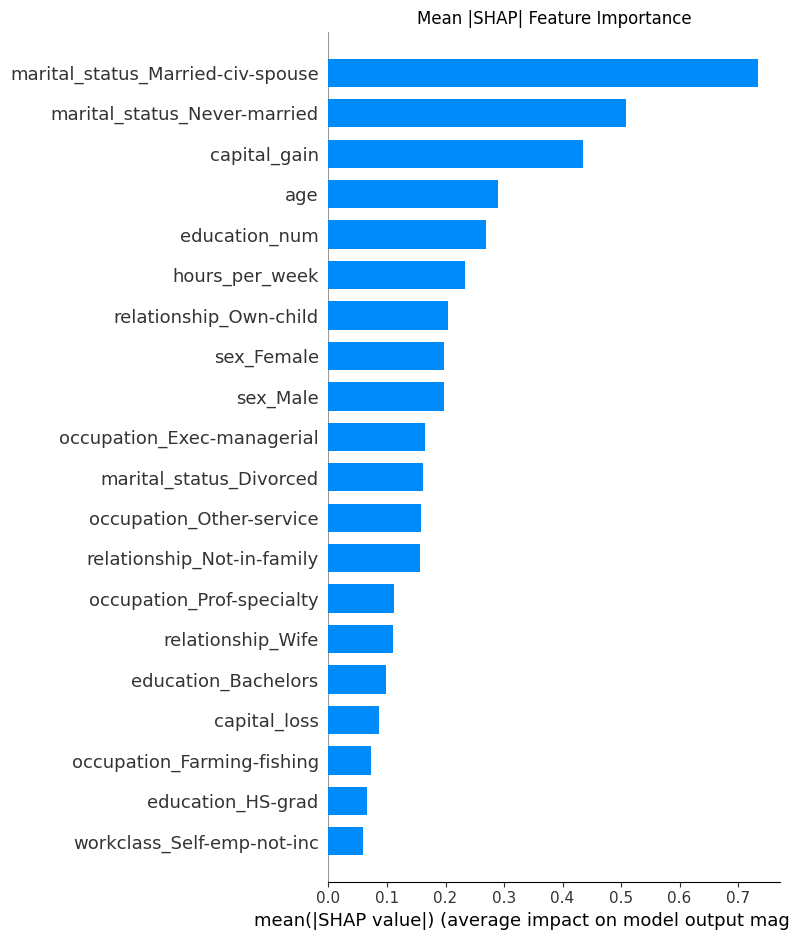

In [15]:
shap.summary_plot(
    shap_values,
    X_test_scaled_df,
    feature_names=X.columns.tolist(),
    plot_type="bar",
    show=False
)

plt.title("Mean |SHAP| Feature Importance")
plt.tight_layout()
save_figure("shap_features.png")

In [16]:
mean_abs_shap = np.abs(shap_values).mean(axis=0)

shap_importance = pd.DataFrame({
    "feature": X.columns,
    "mean_abs_shap": mean_abs_shap
}).sort_values(by="mean_abs_shap", ascending=False)

print("Top 20 SHAP features:")
display(shap_importance.head(20))

print("Top 5 SHAP features:")
display(shap_importance.head(5))

Top 20 SHAP features:
Top 5 SHAP features:


,feature,mean_abs_shap
33,marital_status_Married-civ-spouse,0.734893
35,marital_status_Never-married,0.508058
3,capital_gain,0.435133
0,age,0.289481
2,education_num,0.269730
5,hours_per_week,0.233775
56,relationship_Own-child,0.204319
65,sex_Male,0.197908
64,sex_Female,0.197908
41,occupation_Exec-managerial,0.164329


,feature,mean_abs_shap
33,marital_status_Married-civ-spouse,0.734893
35,marital_status_Never-married,0.508058
3,capital_gain,0.435133
0,age,0.289481
2,education_num,0.269730


## SHAP Feature Group Importance

In [17]:
categorical_cols = [
    "workclass", "education", "marital_status", "occupation",
    "relationship", "race", "sex", "native_country"
]

def get_original_feature_name(encoded_feature):
    for col in categorical_cols:
        if encoded_feature.startswith(col + "_"):
            return col
    return encoded_feature


feature_groups = [get_original_feature_name(col) for col in X.columns]

abs_shap_df = pd.DataFrame(
    np.abs(shap_values),
    columns=X.columns
)

# Sum SHAP importance within each original feature group
grouped_abs_shap = abs_shap_df.T.groupby(feature_groups).sum().T

group_shap_importance = pd.DataFrame({
    "original_feature": grouped_abs_shap.columns,
    "mean_abs_shap": grouped_abs_shap.mean(axis=0)
}).sort_values(by="mean_abs_shap", ascending=False)

proxy_or_protected_features = [
    "sex",
    "relationship",
    "marital_status",
    "occupation",
    "hours_per_week",
    "workclass"
]

group_shap_importance["possible_protected_or_proxy"] = group_shap_importance[
    "original_feature"
].isin(proxy_or_protected_features)

display(group_shap_importance)

,original_feature,mean_abs_shap,possible_protected_or_proxy
marital_status,marital_status,1.492242,True
occupation,occupation,0.774212,True
education,education,0.773842,False
relationship,relationship,0.627222,True
capital_gain,capital_gain,0.435133,False
sex,sex,0.395816,True
age,age,0.289481,False
hours_per_week,hours_per_week,0.233775,True
workclass,workclass,0.233336,True
native_country,native_country,0.155218,False


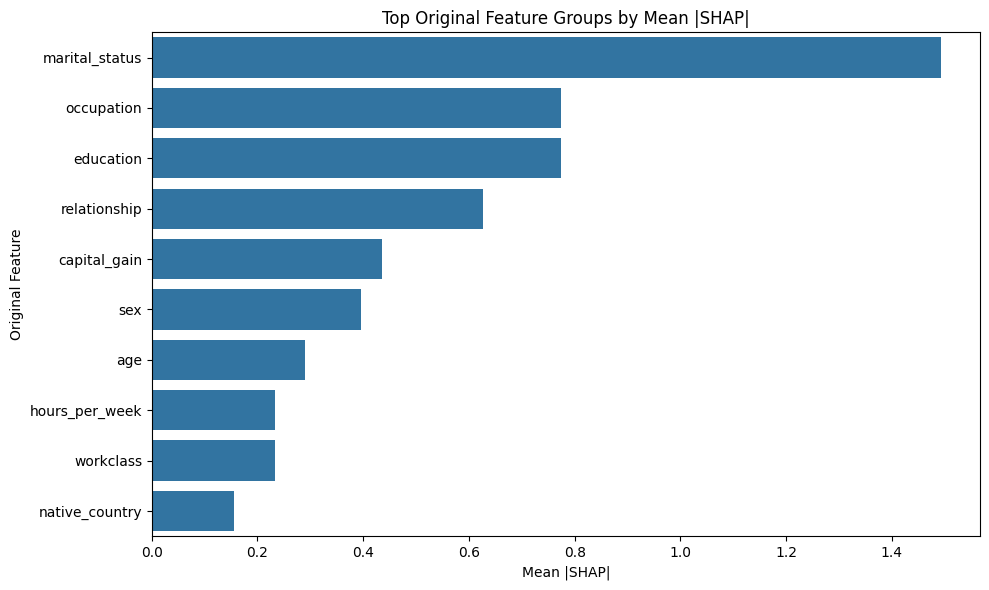

In [18]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=group_shap_importance.head(10),
    x="mean_abs_shap",
    y="original_feature"
)

plt.title("Top Original Feature Groups by Mean |SHAP|")
plt.xlabel("Mean |SHAP|")
plt.ylabel("Original Feature")
plt.tight_layout()
save_figure("shap_feature_groups.png")

## SHAP Local Explanation: One Favorable and One Unfavorable Prediction

In [19]:
# Pick one predicted high-income sample
predicted_positive_indices = np.where(y_pred == 1)[0]
predicted_negative_indices = np.where(y_pred == 0)[0]

positive_local_idx = predicted_positive_indices[0]

# Pick one unfavorable prediction close to the decision boundary
# This is useful for the recourse test too
negative_probs = y_prob[predicted_negative_indices]
negative_local_idx = predicted_negative_indices[np.argmax(negative_probs)]

print("Positive local index:", positive_local_idx)
print("Negative local index:", negative_local_idx)

print("Positive sample probability:", y_prob[positive_local_idx])
print("Negative sample probability:", y_prob[negative_local_idx])

Positive local index: 2
Negative local index: 662
Positive sample probability: 0.9941183125041692
Negative sample probability: 0.499642822142321


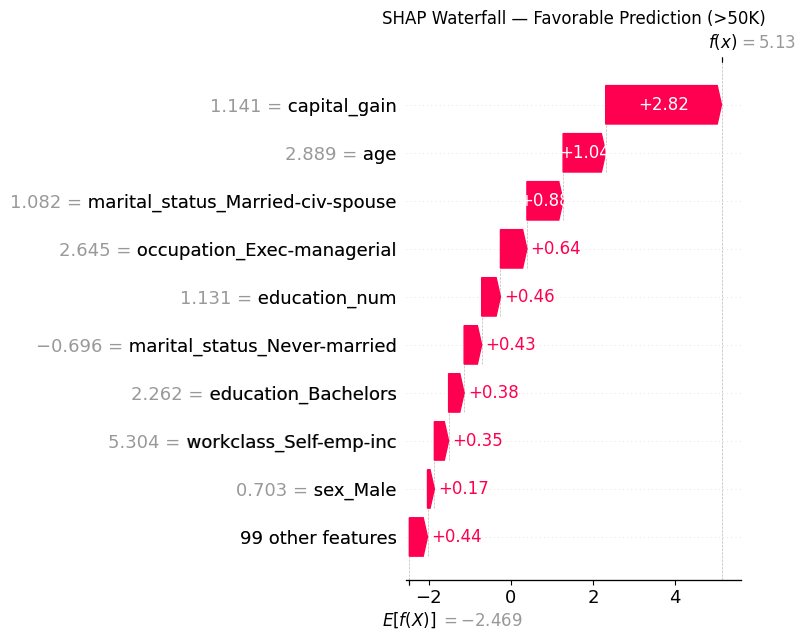

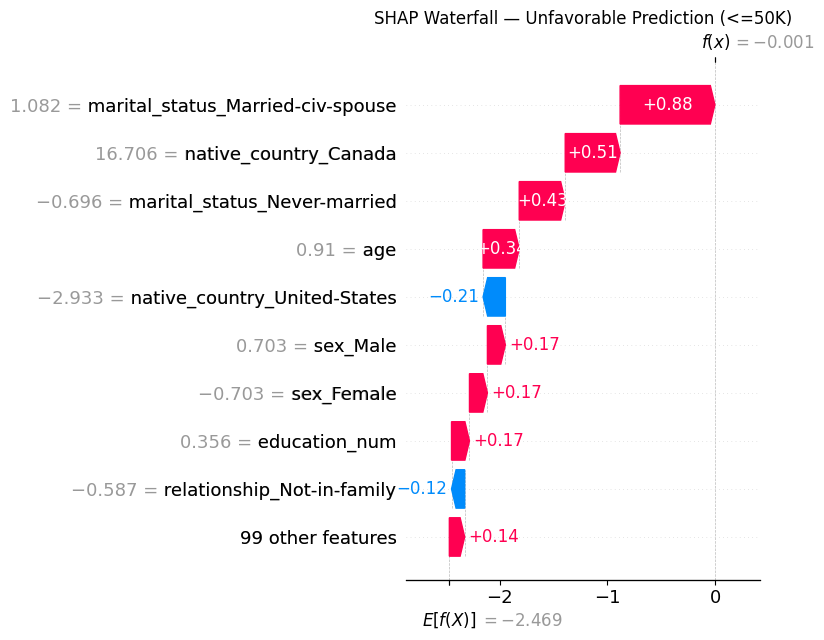

In [20]:
def make_shap_waterfall(local_idx, title):
    base_value = shap_exp.base_values

    if isinstance(base_value, np.ndarray):
        if len(base_value.shape) > 0:
            base_value_single = base_value[local_idx]
        else:
            base_value_single = base_value
    else:
        base_value_single = base_value

    single_exp = shap.Explanation(
        values=shap_values[local_idx],
        base_values=base_value_single,
        data=X_test_scaled_df.iloc[local_idx],
        feature_names=X.columns.tolist()
    )

    shap.plots.waterfall(
        single_exp,
        max_display=10,
        show=False
    )

    plt.title(title)
    plt.tight_layout()
    save_figure("shap_favorable.png" if local_idx == positive_local_idx else "shap_unfavorable.png")


make_shap_waterfall(
    positive_local_idx,
    "SHAP Waterfall — Favorable Prediction (>50K)"
)

make_shap_waterfall(
    negative_local_idx,
    "SHAP Waterfall — Unfavorable Prediction (<=50K)"
)

## LIME Local Explanation

In [21]:
import lime
import lime.lime_tabular

# LIME uses the unscaled one-hot data.
# The prediction function will scale before passing into the model.

def lime_predict_proba(data_as_array):
    data_df = pd.DataFrame(data_as_array, columns=X.columns)

    data_scaled_array = scaler.transform(data_df)

    data_scaled_df = pd.DataFrame(
        data_scaled_array,
        columns=X.columns
    )

    return model.predict_proba(data_scaled_df)


print("Initializing LIME Tabular Explainer...")

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X.columns.tolist(),
    class_names=["<=50K", ">50K"],
    mode="classification",
    discretize_continuous=True,
    random_state=42
)

print("LIME ready.")

Initializing LIME Tabular Explainer...
LIME ready.


LIME Explanation — Favorable Prediction (>50K)
True label: 1
Predicted label: 1
Predicted probability for >50K: 0.9941183125041692

LIME explanation list:
LIME Explanation — Unfavorable Prediction (<=50K)
True label: 1
Predicted label: 0
Predicted probability for >50K: 0.499642822142321

LIME explanation list:


[('capital_gain > 0.00', 0.6654357022557371),
 ('workclass_Never-worked <= 0.00', 0.5043788056023342),
 ('native_country_Cambodia <= 0.00', -0.38456370515598276),
 ('workclass_Without-pay <= 0.00', 0.23160163101342418),
 ('education_Preschool <= 0.00', 0.17137795471662093),
 ('native_country_El-Salvador <= 0.00', 0.1401625993341706),
 ('native_country_Yugoslavia <= 0.00', -0.13489155025701013),
 ('native_country_Dominican-Republic <= 0.00', 0.1341058031223361),
 ('native_country_South <= 0.00', 0.09011229495936889),
 ('native_country_Columbia <= 0.00', 0.02166518907029254)]

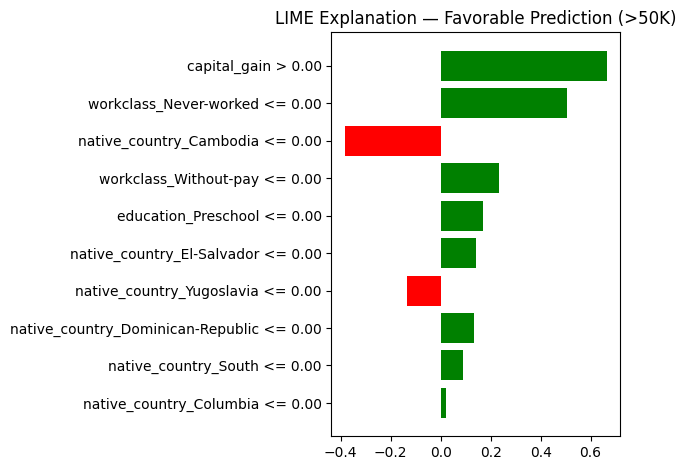

[('capital_gain <= 0.00', -0.6671546863684994),
 ('marital_status_Married-AF-spouse <= 0.00', -0.297840211279667),
 ('relationship_Wife <= 0.00', -0.18279874492024575),
 ('native_country_Columbia <= 0.00', 0.14576164075770323),
 ('native_country_Canada > 0.00', 0.14324652523305723),
 ('education_Preschool <= 0.00', 0.14026450318101794),
 ('occupation_Priv-house-serv <= 0.00', 0.13521970254115567),
 ('native_country_Cambodia <= 0.00', -0.11246353662528265),
 ('workclass_Without-pay <= 0.00', 0.08071283567558094),
 ('occupation_Armed-Forces <= 0.00', 0.058772232311712594)]

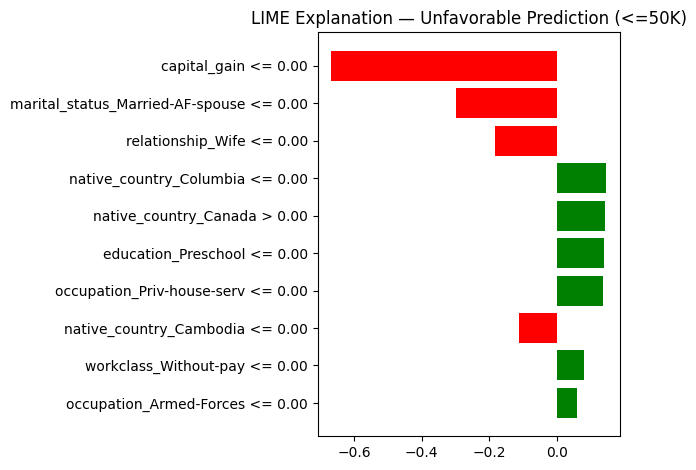

In [22]:
def explain_with_lime(local_idx, title):
    exp = lime_explainer.explain_instance(
        data_row=X_test.iloc[local_idx].values,
        predict_fn=lime_predict_proba,
        num_features=10
    )

    print(title)
    print("True label:", y_test.iloc[local_idx])
    print("Predicted label:", y_pred[local_idx])
    print("Predicted probability for >50K:", y_prob[local_idx])
    print()
    print("LIME explanation list:")
    display(exp.as_list())

    fig = exp.as_pyplot_figure()
    plt.title(title)
    plt.tight_layout()
    save_figure("lime_favorable.png" if local_idx == positive_local_idx else "lime_unfavorable.png")

    return exp


lime_exp_positive = explain_with_lime(
    positive_local_idx,
    "LIME Explanation — Favorable Prediction (>50K)"
)

lime_exp_negative = explain_with_lime(
    negative_local_idx,
    "LIME Explanation — Unfavorable Prediction (<=50K)"
)
lime_rows = []
for name, exp in [("favorable", lime_exp_positive), ("unfavorable", lime_exp_negative)]:
    for feature, weight in exp.as_list():
        lime_rows.append({"example": name, "feature": feature, "weight": weight})
lime_table = pd.DataFrame(lime_rows)


## Recourse Test Setup

In [23]:
raw_feature_cols = [col for col in columns if col != "income"]

# Get the original raw row for the unfavorable prediction
recourse_original_index = X_test.index[negative_local_idx]
recourse_original_row = df.loc[recourse_original_index, raw_feature_cols].copy()

print("Selected unfavorable prediction:")
print("Original dataset index:", recourse_original_index)
print("True income label:", df.loc[recourse_original_index, "income"])
print("Model predicted label:", y_pred[negative_local_idx])
print("Model probability for >50K:", y_prob[negative_local_idx])

display(pd.DataFrame([recourse_original_row]))

Selected unfavorable prediction:
Original dataset index: 30969
True income label: 1
Model predicted label: 0
Model probability for >50K: 0.499642822142321


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country
30969,51,Private,305673,Assoc-voc,11,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40,Canada


In [24]:
def predict_from_raw_row(raw_row):
    """
    raw_row should be a Series or dict containing the original Adult dataset features,
    not one-hot encoded features.
    """

    clean_dict = {}

    for col in raw_feature_cols:
        clean_dict[col] = raw_row[col]

    row_df = pd.DataFrame([clean_dict])

    row_encoded = pd.get_dummies(row_df)
    row_encoded = row_encoded.reindex(columns=X.columns, fill_value=0)

    row_scaled_array = scaler.transform(row_encoded)

    # Preserve feature names when passing scaled data to the model.
    row_scaled_df = pd.DataFrame(
        row_scaled_array,
        columns=X.columns,
        index=row_encoded.index
    )

    prob = model.predict_proba(row_scaled_df)[0, 1]
    pred = int(prob >= 0.5)

    return pred, prob

In [25]:
original_pred, original_prob = predict_from_raw_row(recourse_original_row)

print("Check original prediction from raw row:")
print("Prediction:", original_pred)
print("Probability >50K:", original_prob)

Check original prediction from raw row:
Prediction: 0
Probability >50K: 0.499642822142321


## Recourse Candidate Search

In [26]:

recourse_results = []

def add_recourse_candidate(description, changed_fields, new_row, actionability_note):
    new_pred, new_prob = predict_from_raw_row(new_row)

    recourse_results.append({
        "description": description,
        "changed_fields": ", ".join(changed_fields),
        "num_changed_fields": len(changed_fields),
        "new_pred": new_pred,
        "new_prob_>50K": new_prob,
        "success": new_pred == 1,
        "actionability_note": actionability_note
    })


base_row = recourse_original_row.copy()

# -------------------------------
# Candidate 1: increase work hours
# -------------------------------
hours_candidates = [40, 45, 50, 55, 60]

for h in hours_candidates:
    if h > base_row["hours_per_week"]:
        new_row = base_row.copy()
        new_row["hours_per_week"] = h

        add_recourse_candidate(
            description=f"Increase hours_per_week to {h}",
            changed_fields=["hours_per_week"],
            new_row=new_row,
            actionability_note="Potentially actionable, but may depend on job availability, health, and caregiving responsibilities."
        )


# -------------------------------
# Candidate 2: increase education
# -------------------------------
education_candidates = [
    ("HS-grad", 9),
    ("Some-college", 10),
    ("Assoc-voc", 11),
    ("Assoc-acdm", 12),
    ("Bachelors", 13),
    ("Masters", 14),
    ("Prof-school", 15),
    ("Doctorate", 16)
]

for edu_label, edu_num in education_candidates:
    if edu_num > base_row["education_num"]:
        new_row = base_row.copy()
        new_row["education"] = edu_label
        new_row["education_num"] = edu_num

        add_recourse_candidate(
            description=f"Increase education to {edu_label}",
            changed_fields=["education", "education_num"],
            new_row=new_row,
            actionability_note="Long-term actionable, but costly and not immediately available to everyone."
        )


# -------------------------------
# Candidate 3: change occupation
# -------------------------------
occupation_candidates = [
    "Exec-managerial",
    "Prof-specialty",
    "Tech-support",
    "Sales",
    "Protective-serv"
]

for occ in occupation_candidates:
    if occ != base_row["occupation"]:
        new_row = base_row.copy()
        new_row["occupation"] = occ

        add_recourse_candidate(
            description=f"Change occupation to {occ}",
            changed_fields=["occupation"],
            new_row=new_row,
            actionability_note="Partly actionable, but depends on labor market access, training, and hiring opportunity."
        )


# -------------------------------
# Candidate 4: change workclass
# -------------------------------
workclass_candidates = [
    "Private",
    "Self-emp-inc",
    "Federal-gov",
    "State-gov",
    "Local-gov"
]

for wc in workclass_candidates:
    if wc != base_row["workclass"]:
        new_row = base_row.copy()
        new_row["workclass"] = wc

        add_recourse_candidate(
            description=f"Change workclass to {wc}",
            changed_fields=["workclass"],
            new_row=new_row,
            actionability_note="Partly actionable, but not fully under the individual's control."
        )


# -------------------------------
# Candidate 5: combinations
# education + hours
# -------------------------------
for edu_label, edu_num in education_candidates:
    for h in hours_candidates:
        if edu_num > base_row["education_num"] and h > base_row["hours_per_week"]:
            new_row = base_row.copy()
            new_row["education"] = edu_label
            new_row["education_num"] = edu_num
            new_row["hours_per_week"] = h

            add_recourse_candidate(
                description=f"Increase education to {edu_label} and hours_per_week to {h}",
                changed_fields=["education", "education_num", "hours_per_week"],
                new_row=new_row,
                actionability_note="Possible but difficult; requires both education access and ability to work more hours."
            )


# -------------------------------
# Candidate 6: occupation + hours
# -------------------------------
for occ in occupation_candidates:
    for h in hours_candidates:
        if occ != base_row["occupation"] and h > base_row["hours_per_week"]:
            new_row = base_row.copy()
            new_row["occupation"] = occ
            new_row["hours_per_week"] = h

            add_recourse_candidate(
                description=f"Change occupation to {occ} and hours_per_week to {h}",
                changed_fields=["occupation", "hours_per_week"],
                new_row=new_row,
                actionability_note="Partly actionable, but depends on job access and ability to work more hours."
            )


# -------------------------------
# Candidate 7: education + occupation
# -------------------------------
for edu_label, edu_num in education_candidates:
    for occ in occupation_candidates:
        if edu_num > base_row["education_num"] and occ != base_row["occupation"]:
            new_row = base_row.copy()
            new_row["education"] = edu_label
            new_row["education_num"] = edu_num
            new_row["occupation"] = occ

            add_recourse_candidate(
                description=f"Increase education to {edu_label} and change occupation to {occ}",
                changed_fields=["education", "education_num", "occupation"],
                new_row=new_row,
                actionability_note="Long-term possible, but may be expensive and unequal across social groups."
            )


recourse_df = pd.DataFrame(recourse_results)

recourse_df = recourse_df.sort_values(
    by=["success", "num_changed_fields", "new_prob_>50K"],
    ascending=[False, True, False]
)

display(recourse_df.head(20))

,description,changed_fields,num_changed_fields,new_pred,new_prob_>50K,success,actionability_note
9,Change occupation to Exec-managerial,occupation,1,1,0.662842,True,"Partly actionable, but depends on labor market..."
3,Increase hours_per_week to 60,hours_per_week,1,1,0.645598,True,"Potentially actionable, but may depend on job ..."
15,Change workclass to Federal-gov,workclass,1,1,0.632231,True,"Partly actionable, but not fully under the ind..."
11,Change occupation to Tech-support,occupation,1,1,0.630894,True,"Partly actionable, but depends on labor market..."
13,Change occupation to Protective-serv,occupation,1,1,0.623947,True,"Partly actionable, but depends on labor market..."
2,Increase hours_per_week to 55,hours_per_week,1,1,0.610509,True,"Potentially actionable, but may depend on job ..."
10,Change occupation to Prof-specialty,occupation,1,1,0.607965,True,"Partly actionable, but depends on labor market..."
1,Increase hours_per_week to 50,hours_per_week,1,1,0.574236,True,"Potentially actionable, but may depend on job ..."
14,Change workclass to Self-emp-inc,workclass,1,1,0.558222,True,"Partly actionable, but not fully under the ind..."
12,Change occupation to Sales,occupation,1,1,0.541695,True,"Partly actionable, but depends on labor market..."


## Successful Recourse Options Only

In [27]:
successful_recourse = recourse_df[recourse_df["success"] == True].copy()

if len(successful_recourse) == 0:
    print("No successful recourse found using the tested actionable changes.")
else:
    print("Successful recourse options:")
    display(successful_recourse.head(10))

Successful recourse options:


,description,changed_fields,num_changed_fields,new_pred,new_prob_>50K,success,actionability_note
9,Change occupation to Exec-managerial,occupation,1,1,0.662842,True,"Partly actionable, but depends on labor market..."
3,Increase hours_per_week to 60,hours_per_week,1,1,0.645598,True,"Potentially actionable, but may depend on job ..."
15,Change workclass to Federal-gov,workclass,1,1,0.632231,True,"Partly actionable, but not fully under the ind..."
11,Change occupation to Tech-support,occupation,1,1,0.630894,True,"Partly actionable, but depends on labor market..."
13,Change occupation to Protective-serv,occupation,1,1,0.623947,True,"Partly actionable, but depends on labor market..."
2,Increase hours_per_week to 55,hours_per_week,1,1,0.610509,True,"Potentially actionable, but may depend on job ..."
10,Change occupation to Prof-specialty,occupation,1,1,0.607965,True,"Partly actionable, but depends on labor market..."
1,Increase hours_per_week to 50,hours_per_week,1,1,0.574236,True,"Potentially actionable, but may depend on job ..."
14,Change workclass to Self-emp-inc,workclass,1,1,0.558222,True,"Partly actionable, but not fully under the ind..."
12,Change occupation to Sales,occupation,1,1,0.541695,True,"Partly actionable, but depends on labor market..."


## Save Important Results

In [28]:
tables = {
    'overall_metrics.csv': overall_metrics,
    'group_fairness_metrics.csv': group_metrics,
    'fairness_disparities.csv': disparity_table,
    'threshold_sensitivity.csv': threshold_conflict,
    'shap_feature_importance.csv': shap_importance,
    'shap_group_importance.csv': group_shap_importance,
    'lime_local_explanations.csv': lime_table,
    'recourse_candidates.csv': recourse_df,
}
for filename, table in tables.items():
    table.to_csv(OUTPUT_DIR / filename, index=False)
run_metadata = {
    'dataset_sha256': hashlib.sha256(DATA_PATH.read_bytes()).hexdigest(),
    'n_rows': len(df), 'n_train': len(X_train), 'n_test': len(X_test),
    'n_encoded_features': len(X.columns), 'seed': 42, 'decision_threshold': 0.5,
    'missing_value_policy': 'Keep ? as Unknown',
    'category_vocabulary': 'One-hot vocabulary established before the split to preserve the baseline',
    'scaler': 'StandardScaler fitted only on training rows',
    'model': 'LogisticRegression(C=1.0, solver=lbfgs, max_iter=5000)',
    'versions': {name: importlib.metadata.version(name) for name in
                 ['numpy', 'pandas', 'scikit-learn', 'matplotlib', 'seaborn', 'shap', 'lime']},
    'python': platform.python_version(),
    'local_examples': {
        'favorable': {'dataset_index': int(X_test.index[positive_local_idx]), 'probability': float(y_prob[positive_local_idx])},
        'unfavorable': {'dataset_index': int(X_test.index[negative_local_idx]), 'probability': float(y_prob[negative_local_idx])}
    },
    'recourse_successes': int(recourse_df['success'].sum()),
    'recourse_candidates': len(recourse_df),
}
(OUTPUT_DIR / 'run_metadata.json').write_text(json.dumps(run_metadata, indent=2) + '\n')
print('Saved result tables and figures.')


Saved result tables and figures.


## Interpretation and limits

Compare selection rate, true positive rate, false positive rate, and positive predictive value together. The threshold sweep uses the held-out test set for descriptive analysis; it does not validate a deployment threshold. SHAP values for this linear classifier are in log-odds units. LIME perturbations can generate invalid one-hot combinations. Recourse candidates are hypothetical model inputs and do not establish causal, feasible, or fair actions.

The benchmark records only Female and Male sex categories and is based on historical census data. It does not measure gender identity or job qualification. The baseline includes `fnlwgt` as a predictor and does not use survey-weighted metrics. Category vocabulary is established before splitting to reproduce the original analysis; future work should fit an encoder only on training rows and evaluate on independent data. See the report for governance implications.